# RNA ATAC integration

In [ ]:

import matplotlib.pyplot as plt
import scanpy as sc
import scvi
import sys
sys.path.append("/home/anirudhn/Krushna/ATAC_Support/multiHIVE/")
from src.model import multiHIVE
import torch

/home/anirudhn/anaconda3/envs/multiVI/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/anirudhn/anaconda3/envs/multiVI/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [3]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)
torch.set_float32_matmul_precision("high")

Seed set to 0


Last run with scvi-tools version: 1.3.0


In [4]:
adata = sc.read_h5ad( "/home/anirudhn/Krushna/Data/Brain-ISSAAC/Brain-ISSAAC-seq.h5ad")
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 10361 × 197472
    obs: 'cell_type', 'batch'
    var: 'modality'

In [6]:
adata = scvi.data.organize_multiome_anndatas(adata)
adata = adata[:, adata.var["modality"].argsort()].copy()
sc.pp.filter_genes(adata, min_cells=int(adata.shape[0] * 0.01))
multiHIVE.setup_anndata(adata, batch_key="modality")
adata

/tmp/ipykernel_847404/2925036252.py:4: DeprecationWarning: multiHIVE is supposed to work with MuData. the use of anndata is deprecated and will be removed in scvi-tools 1.4. Please use setup_mudata
  multiHIVE.setup_anndata(adata, batch_key="modality")


AnnData object with n_obs × n_vars = 10361 × 174205
    obs: 'cell_type', 'batch', 'modality', '_indices', '_scvi_batch', '_scvi_labels'
    var: 'modality', 'n_cells'
    uns: '_scvi_uuid', '_scvi_manager_uuid'

In [7]:
vae = multiHIVE(adata, latent_distribution="normal",
                n_genes=(adata.var["modality"] == "Gene Expression").sum(),
                n_regions=(adata.var["modality"] == "Peaks").sum(),
                n_proteins=0,
                kl_dot_product  = True,
                deep_network = False,
               )

Encoder(
  (encoder_r_1): Sequential(
    (0): Linear(in_features=174206, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
  )
  (z_mean_encoder_delta_1): Linear(in_features=128, out_features=20, bias=True)
  (z_var_encoder_delta_1): Linear(in_features=128, out_features=20, bias=True)
  (encoder_r_2): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=0.001, momentum=0.01, affine=True, track_running_st

In [ ]:
vae.train(max_epochs=300, early_stopping=False)

# generated_data = vae.posterior_predictive_sample(adata, swap_latent=False)
# rna_sample = generated_data[:,:hvg].copy()
# proteins_sample = pd.DataFrame(generated_data[:,hvg:],  index= adata.obs_names, columns = adata.obsm['protein_counts'].columns)
# adata.obsm['RNA_Z1_denoised'] = rna_sample
# adata.obsm['protein_Z1_denoised'] = proteins_sample

# generated_data = vae.posterior_predictive_sample(adata, swap_latent=True)
# rna_sample = generated_data[:,:hvg].copy()
# proteins_sample = pd.DataFrame(generated_data[:,hvg:],  index= adata.obs_names, columns = adata.obsm['protein_counts'].columns)
# adata.obsm['RNA_Z2_denoised'] = rna_sample
# adata.obsm['protein_Z2_denoised'] = proteins_sample

In [9]:
vae.get_latent_representation()

Zc_multiHIVE


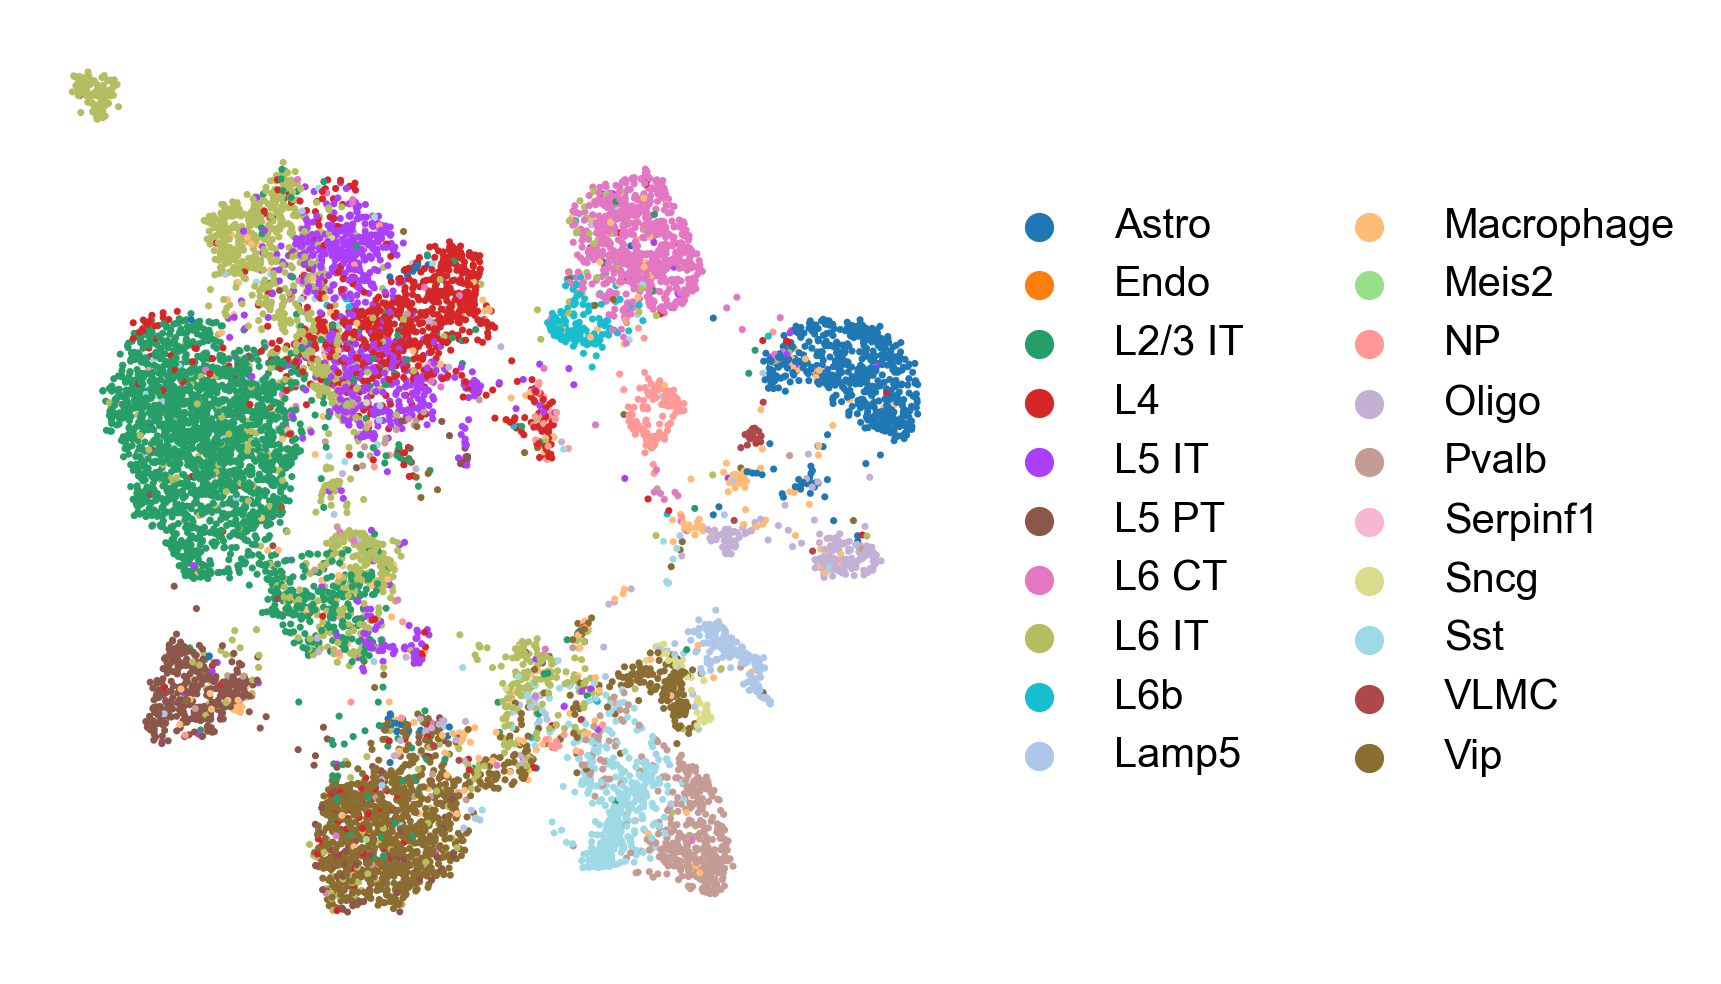

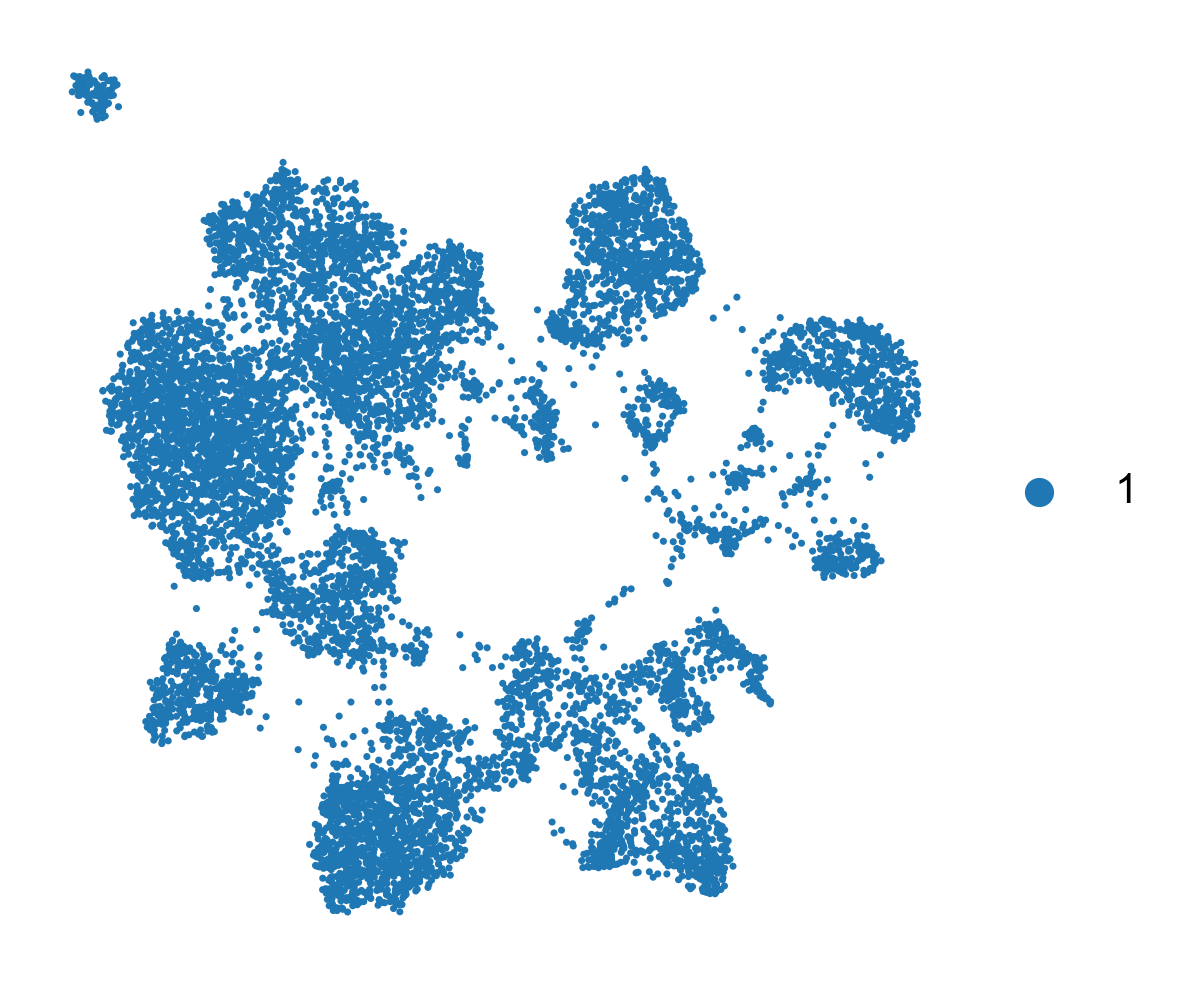

In [ ]:
sc.pp.neighbors(adata, use_rep='Z_multiHIVE')
sc.tl.umap(adata)
sc.pl.umap(adata,color=['cell_type'], frameon= False, return_fig = True, title='')
sc.pl.umap(adata,color=['batch'], frameon= False, return_fig = True, title='')  
